<a href="https://colab.research.google.com/github/ilchukmark/Analytics/blob/main/Business_Analysis_with_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import drive

drive.mount("/content/drive")
%cd /content/drive/MyDrive/Mate_homework/final_project

products = pd.read_csv("products.csv")
countries = pd.read_csv("countries.csv")
events = pd.read_csv("events.csv")

def inspect_dataframe(df, name):
    print(f"Аналіз таблиці: {name}")
    print(f"Розмірність: {df.shape[0]} рядків, {df.shape[1]} колонок\n")
    print("Інформація про типи та пропуски:")
    print(df.info())
    print("\nКількість пропусків по колонках:")
    print(df.isna().sum())


inspect_dataframe(products, "PRODUCTS")
inspect_dataframe(countries, "COUNTRIES")
inspect_dataframe(events, "EVENTS")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Mate_homework/final_project
Аналіз таблиці: PRODUCTS
Розмірність: 12 рядків, 2 колонок

Інформація про типи та пропуски:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes
None

Кількість пропусків по колонках:
id           0
item_type    0
dtype: int64
Аналіз таблиці: COUNTRIES
Розмірність: 249 рядків, 5 колонок

Інформація про типи та пропуски:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2 

In [ ]:

events["Order Date"] = pd.to_datetime(events["Order Date"])
events["Ship Date"] = pd.to_datetime(events["Ship Date"])


# Видаляю 2 рядки, оскільки всього 2 пропуски з 1330 — це 0.15%
events = events.dropna(subset=["Units Sold"])
# Переводжу в ціле число, оскільки штучний товар не може бути дробовим
events["Units Sold"] = events["Units Sold"].astype(int)

# Оскільки ми не знаємо країну, замінимо пропуски на 'UNKNOWN', бо 82 пропуски це надто багато щоб видаляти
events["Country Code"] = events["Country Code"].fillna("UNKNOWN")

missing_country_rows = countries[countries.isna().any(axis=1)]
print("Пропущені гео-дані в таблиці COUNTRIES:")
display(missing_country_rows)

countries["alpha-2"] = countries["alpha-2"].fillna("NA")
countries["region"] = countries["region"].fillna("Unknown")
countries["sub-region"] = countries["sub-region"].fillna("Unknown")


products["item_type"] = products["item_type"].str.strip()
countries["name"] = countries["name"].str.strip()

print(f"Дублікатів у PRODUCTS: {products.duplicated().sum()}")
print(f"Дублікатів у COUNTRIES: {countries.duplicated().sum()}")
print(f"Дублікатів у EVENTS: {events.duplicated().sum()}")

print("\nСтан таблиці EVENTS після першої чистки:")
print(events.info())

Пропущені гео-дані в таблиці COUNTRIES:


,name,alpha-2,alpha-3,region,sub-region
8,Antarctica,AQ,ATA,NaN,NaN
153,Namibia,NaN,NAM,Africa,Sub-Saharan Africa


Дублікатів у PRODUCTS: 0
Дублікатів у COUNTRIES: 0
Дублікатів у EVENTS: 0

Стан таблиці EVENTS після першої чистки:
<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1328 non-null   int64         
 1   Order Date      1328 non-null   datetime64[ns]
 2   Ship Date       1328 non-null   datetime64[ns]
 3   Order Priority  1328 non-null   object        
 4   Country Code    1328 non-null   object        
 5   Product ID      1328 non-null   int64         
 6   Sales Channel   1328 non-null   object        
 7   Units Sold      1328 non-null   int64         
 8   Unit Price      1328 non-null   float64       
 9   Unit Cost       1328 non-null   float64       
dtypes: datetime64[ns](2), float64(2), int64(3), object(3)
memory usage: 114.1+ KB
None


In [ ]:
# Перевіряю, чи є замовлення, де відвантаження відбулося раніше, ніж саме замовлення
date_anomaly = events[events["Ship Date"] < events["Order Date"]]
print(f"Кількість аномалій з датами (Ship Date < Order Date): {len(date_anomaly)}")

# Швидка перевірка
display(events[["Units Sold", "Unit Price", "Unit Cost"]].describe())


full_df = pd.merge(
    events, products, left_on="Product ID", right_on="id", how="left"
)

full_df = pd.merge(
    full_df, countries, left_on="Country Code", right_on="alpha-3", how="left"
)

full_df = full_df.drop(columns=["id", "alpha-3"])

full_df.columns = (
    full_df.columns.str.lower().str.replace(" ", "_").str.replace("-", "_")
)

print(f"Розмірність об'єднаного датасету: {full_df.shape}")
print("\nКолонки фінального датафрейму:")
print(full_df.columns.tolist())

Кількість аномалій з датами (Ship Date < Order Date): 0


,Units Sold,Unit Price,Unit Cost
count,1328.000000,1328.000000,1328.000000
mean,4952.201807,264.913245,187.211521
std,2905.198996,217.386320,176.187801
min,2.000000,9.330000,6.920000
25%,2356.750000,81.730000,35.840000
50%,4962.000000,154.060000,97.440000
75%,7459.500000,437.200000,263.330000
max,9999.000000,668.270000,524.960000


Розмірність об'єднаного датасету: (1328, 15)

Колонки фінального датафрейму:
['order_id', 'order_date', 'ship_date', 'order_priority', 'country_code', 'product_id', 'sales_channel', 'units_sold', 'unit_price', 'unit_cost', 'item_type', 'name', 'alpha_2', 'region', 'sub_region']


In [ ]:
# 1. Загальний дохід
full_df["total_revenue"] = full_df["units_sold"] * full_df["unit_price"]

# 2. Загальні витрати
full_df["total_cost"] = full_df["units_sold"] * full_df["unit_cost"]

# 3. Чистий прибуток
full_df["total_profit"] = full_df["total_revenue"] - full_df["total_cost"]

# 4. Час доставки
full_df["days_to_ship"] = (
    full_df["ship_date"] - full_df["order_date"]
).dt.days


total_orders = full_df["order_id"].nunique()
total_revenue = full_df["total_revenue"].sum()
total_profit = full_df["total_profit"].sum()
total_units = full_df["units_sold"].sum()
total_countries = full_df[full_df["country_code"] != "UNKNOWN"][
    "name"
].nunique()
avg_shipping_time = full_df["days_to_ship"].mean()

print(f"Загальна кількість замовлень:     {total_orders:,}")
print(f"Загальна кількість проданих шт:  {total_units:,}")
print(f"Загальний дохід (Revenue):       ${total_revenue:,.2f}")
print(f"Загальний прибуток (Profit):     ${total_profit:,.2f}")
print(f"Кількість охоплених країн:       {total_countries}")
print(f"Середній час відвантаження:      {avg_shipping_time:.1f} днів")

Загальна кількість замовлень:     1,328
Загальна кількість проданих шт:  6,576,524
Загальний дохід (Revenue):       $1,702,129,408.21
Загальний прибуток (Profit):     $501,434,459.00
Кількість охоплених країн:       45
Середній час відвантаження:      24.8 днів


/tmp/ipykernel_419/493856355.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


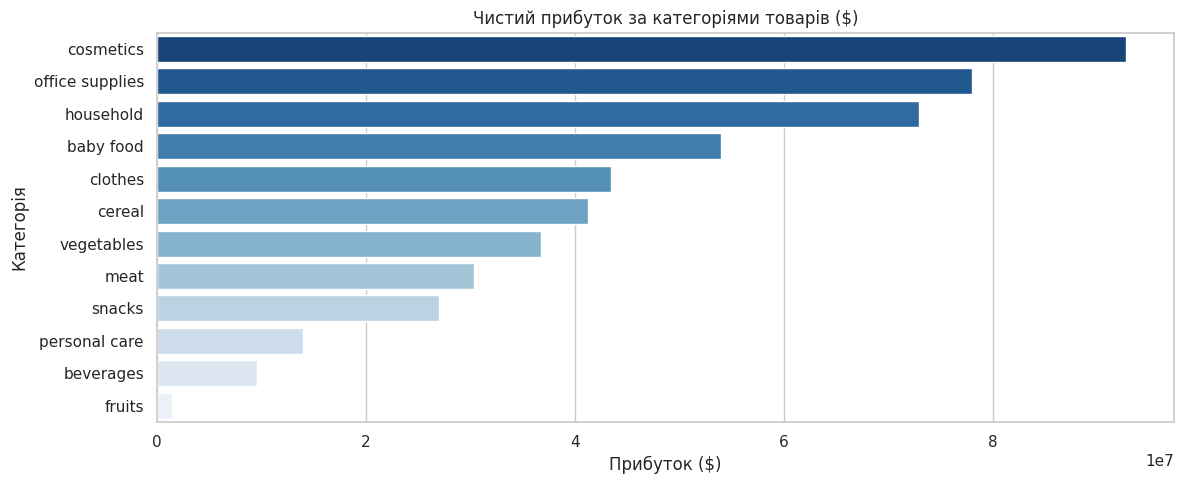

/tmp/ipykernel_419/493856355.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


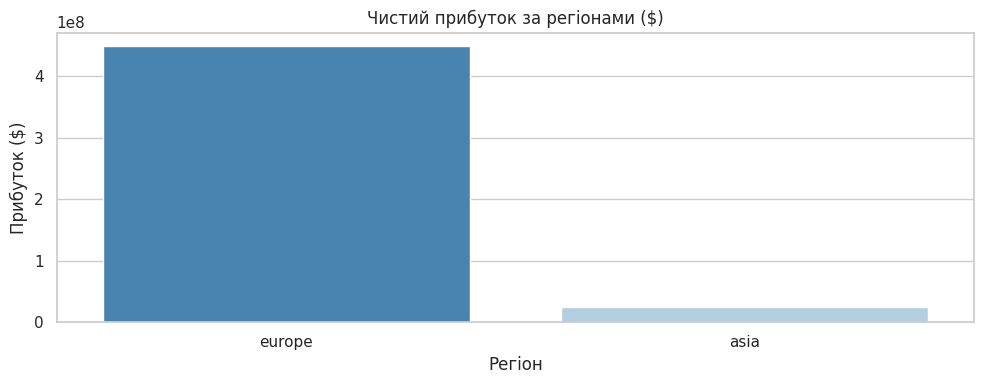

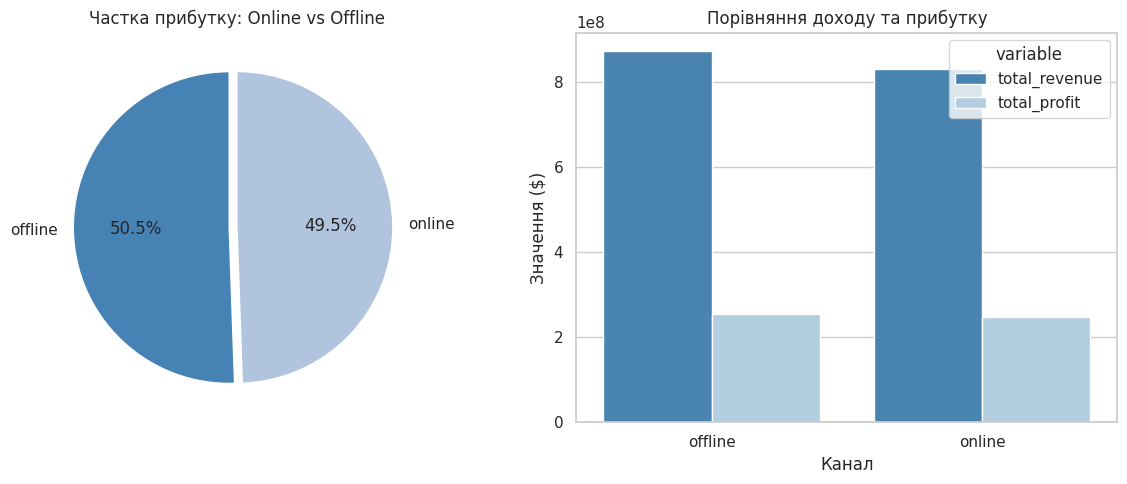

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

full_df["sales_channel"] = full_df["sales_channel"].str.lower().str.strip()
full_df["item_type"] = full_df["item_type"].str.lower().str.strip()
if "region" in full_df.columns:
    full_df["region"] = full_df["region"].str.lower().str.strip()

# 1. Аналіз категорій товару
product_analysis = (
    full_df.groupby("item_type")["total_profit"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 5))
sns.barplot(
    x=product_analysis.values, y=product_analysis.index, palette="Blues_r"
)
plt.title("Чистий прибуток за категоріями товарів ($)")
plt.xlabel("Прибуток ($)")
plt.ylabel("Категорія")
plt.tight_layout()
plt.show()

# 2. Аналіз географії
region_analysis = (
    full_df.groupby("region")["total_profit"].sum().sort_values(ascending=False)
)

plt.figure(figsize=(10, 4))
sns.barplot(
    x=region_analysis.index, y=region_analysis.values, palette="Blues_r"
)
plt.title("Чистий прибуток за регіонами ($)")
plt.ylabel("Прибуток ($)")
plt.xlabel("Регіон")
plt.tight_layout()
plt.show()

# 3. Аналіз каналів продажу
channel_analysis = full_df.groupby("sales_channel")[
    ["total_revenue", "total_profit"]
].sum()
num_channels = len(channel_analysis)
explode_val = [0.05] + [0] * (num_channels - 1) if num_channels > 1 else None

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].pie(
    channel_analysis["total_profit"],
    labels=channel_analysis.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4682B4", "#B0C4DE"][:num_channels],
    explode=explode_val,
)
ax[0].set_title("Частка прибутку: Online vs Offline")

channel_df_melted = channel_analysis.reset_index().melt(
    id_vars="sales_channel", value_vars=["total_revenue", "total_profit"]
)
sns.barplot(
    data=channel_df_melted,
    x="sales_channel",
    y="value",
    hue="variable",
    ax=ax[1],
    palette="Blues_r",
)
ax[1].set_title("Порівняння доходу та прибутку")
ax[1].set_ylabel("Значення ($)")
ax[1].set_xlabel("Канал")

plt.tight_layout()
plt.show()

/tmp/ipykernel_419/1354422309.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


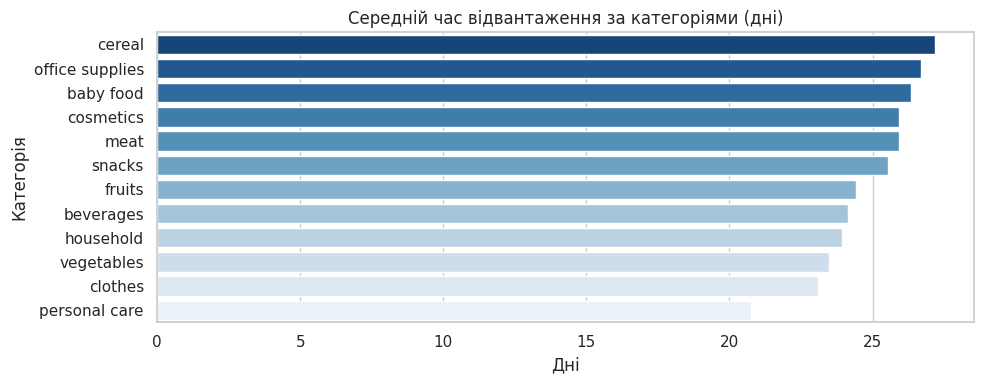

/tmp/ipykernel_419/1354422309.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ship_by_region.index, y=ship_by_region.values, palette="Blues_r")


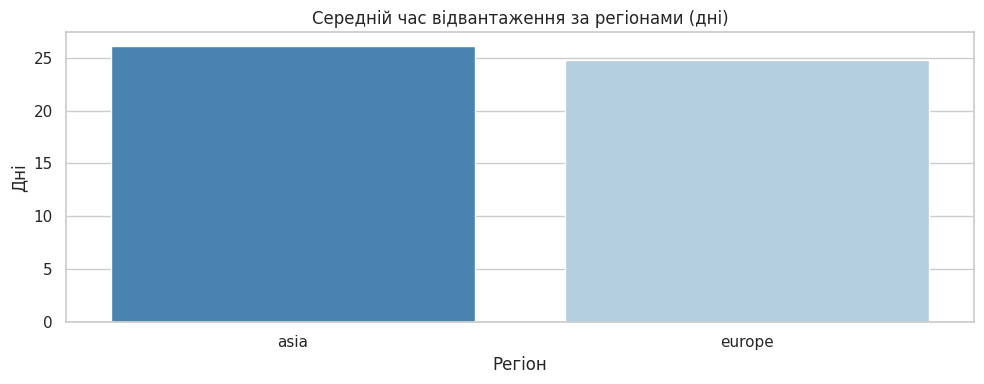

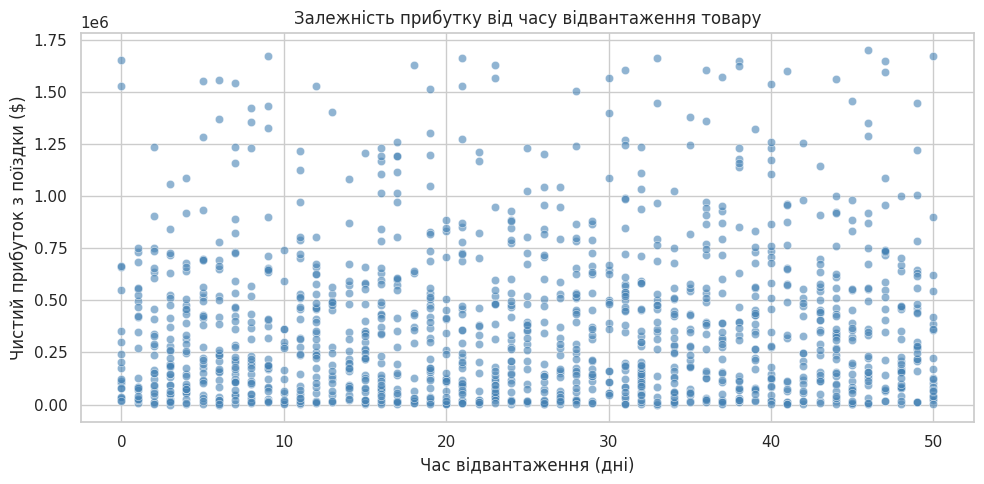

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Середній час відвантаження за категоріями товарів
ship_by_product = (
    full_df.groupby("item_type")["days_to_ship"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 4))
sns.barplot(
    x=ship_by_product.values, y=ship_by_product.index, palette="Blues_r"
)
plt.title("Середній час відвантаження за категоріями (дні)")
plt.xlabel("Дні")
plt.ylabel("Категорія")
plt.tight_layout()
plt.show()

# Середній час відвантаження за регіонами
ship_by_region = (
    full_df.groupby("region")["days_to_ship"].mean().sort_values(ascending=False)
)

plt.figure(figsize=(10, 4))
sns.barplot(x=ship_by_region.index, y=ship_by_region.values, palette="Blues_r")
plt.title("Середній час відвантаження за регіонами (дні)")
plt.ylabel("Дні")
plt.xlabel("Регіон")
plt.tight_layout()
plt.show()

# Аналіз залежності прибутку від часу відвантаження
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=full_df, x="days_to_ship", y="total_profit", alpha=0.6, color="#4682B4"
)
plt.title("Залежність прибутку від часу відвантаження товару")
plt.xlabel("Час відвантаження (дні)")
plt.ylabel("Чистий прибуток з поїздки ($)")
plt.tight_layout()
plt.show()

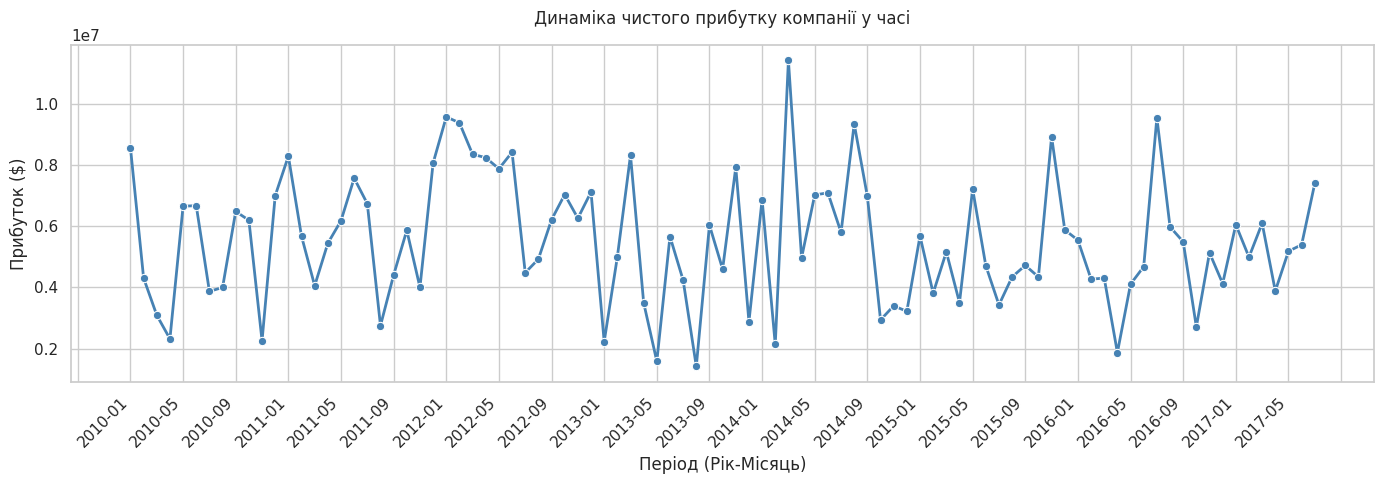

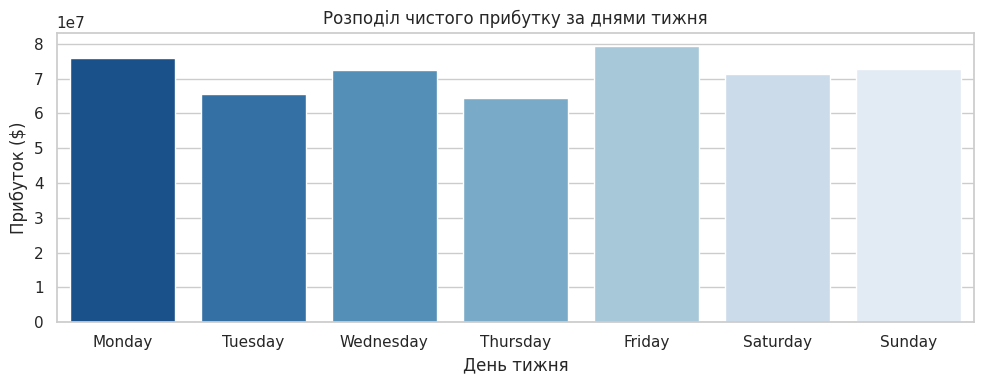

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style="whitegrid")

# Створюю колонку року та місяця
full_df["year_month"] = full_df["order_date"].dt.to_period("M")
time_analysis = (
    full_df.groupby("year_month")["total_profit"].sum().reset_index()
)
time_analysis["year_month"] = time_analysis["year_month"].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(
    data=time_analysis,
    x="year_month",
    y="total_profit",
    marker="o",
    color="#4682B4",
    linewidth=2,
    ax=ax,
)

# Корекція осі Х
ax.xaxis.set_major_locator(ticker.MultipleLocator(4))

plt.title("Динаміка чистого прибутку компанії у часі", pad=15)
plt.xlabel("Період (Рік-Місяць)")
plt.ylabel("Прибуток ($)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Визначаю день тижня
full_df["day_of_week"] = full_df["order_date"].dt.day_name()

# Задаю правильний порядок днів тижня для графіка
days_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

day_analysis = (
    full_df.groupby("day_of_week")["total_profit"].sum().reindex(days_order)
)

plt.figure(figsize=(10, 4))
sns.barplot(
    x=day_analysis.index,
    y=day_analysis.values,
    hue=day_analysis.index,
    palette="Blues_r",
    legend=False,
)
plt.title("Розподіл чистого прибутку за днями тижня")
plt.xlabel("День тижня")
plt.ylabel("Прибуток ($)")
plt.tight_layout()
plt.show()

# **Ключові аналітичні інсайти проєкту**
Середній час відвантаження товару по компанії становить майже 25 днів, що є довгим операційним циклом. Проте кореляційний аналіз виявив закономірність: сума чистого прибутку з окремої транзакції взагалі не падає із затримкою доставки. Це свідчить про низьку еластичність попиту за часом — компанія продає або унікальний продукт, або має ексклюзивне становище на ринках збуту, де клієнти не мають швидких альтернатив.
## Омніканальний баланс та диверсифікація ризиків
Розподіл чистого прибутку між онлайн та офлайн каналами зафіксувався на позначці практично 50 на 50. Компанія однаково ефективно конвертує як цифровий трафік, так і класичний фізичний ритейл. Структура витрат та доходу в обох каналах є дзеркальною, що мінімізує ризики компанії: якщо в одному з регіонів відбудеться локальний локдаун чи падіння фізичного трафіку, онлайн-канал повністю закриє цю прогалину без втрати загальної маржі.
## Стабільність операційного навантаження (Відсутність "ефекту вихідних")
Прибуток розподілений по днях тижня абсолютно рівномірно. Для бізнесу це перевага в операційному менеджменті: склади, логістичні хаби та менеджери підтримки працюють в умовах прогнозованого, стабільного щоденного навантаження.
## Хвильова природа фінансових потоків
Попри загальну фінансову стабільність, графік динаміки у часі нагадує кардіограму з постійними різкими коливаннями. Бізнес не має довгострокового тренду на згасання, але кожен локальний пік супроводжується таким же стрімким спадом у наступному місяці. Оскільки часової залежності від днів тижня не було помічено, ці коливання, скоріш за все, викликані специфікою бізнесу